In [ ]:
!pip install datasets scikit-image opencv-python-headless lightgbm -q

Persistence in Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/ml_project'
os.makedirs(PROJECT_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading Dataset from HF

In [ ]:
!pip install datasets -q
from datasets import load_dataset

ds = load_dataset("Rajarshi-Roy-research/Defactify_Image_Dataset")
print(ds)

README.md:   0%|          | 0.00/5.11k [00:00<?, ?B/s]

data/validation-00000-of-00002.parquet:   0%|          | 0.00/333M [00:00<?, ?B/s]

data/validation-00001-of-00002.parquet:   0%|          | 0.00/345M [00:00<?, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/448M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/445M [00:00<?, ?B/s]

...

data/test-00007-of-00008.parquet:   0%|          | 0.00/449M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/42000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/45000 [00:00<?, ? examples/s]

DatasetDict({
    validation: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 9000
    })
    train: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 42000
    })
    test: Dataset({
        features: ['Caption', 'Image', 'Label_A', 'Label_B'],
        num_rows: 45000
    })
})


Exploring the dataset

In [ ]:
data = ds['train']

print(data[0])
print()
print("Label_A unique values:", set(data['Label_A'][:2000]))
print("Label_B unique values:", set(data['Label_B'][:2000]))

{'Caption': 'Two tall giraffe standing next to each other on a  field.', 'Image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480 at 0x78494E963CB0>, 'Label_A': 0, 'Label_B': 0}

Label_A unique values: {0, 1}
Label_B unique values: {0, 1, 2, 3, 4, 5}


In [ ]:
import pandas as pd
label_b_counts = pd.Series(data['Label_B']).value_counts().sort_index()
print(label_b_counts)


0    7000
1    7000
2    7000
3    7000
4    7000
5    7000
Name: count, dtype: int64


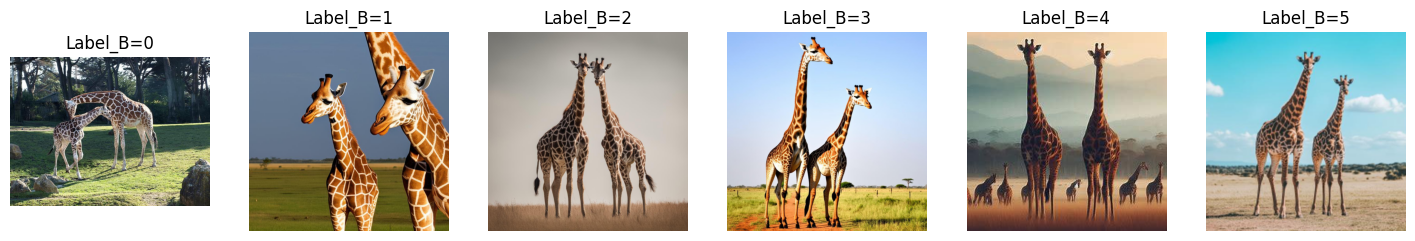

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 6, figsize=(18,3))
for label_val in range(6):
    idx = data['Label_B'].index(label_val)  # first occurrence of this label
    img = data[idx]['Image']
    axes[label_val].imshow(img)
    axes[label_val].set_title(f'Label_B={label_val}')
    axes[label_val].axis('off')
plt.show()

Sampling Data

In [ ]:
import random
random.seed(42)

def sample_by_label_b(dataset, label_val, n=800):
    indices = [i for i, x in enumerate(dataset['Label_B']) if x == label_val]
    chosen_idx = random.sample(indices, min(n, len(indices)))
    return dataset.select(chosen_idx)

label_map = {0: 'Real', 1: 'SD21', 2: 'SDXL', 3: 'SD3', 4: 'DALLE3', 5: 'Midjourney'}

subsets = {}
for label_val, gen_name in label_map.items():
    subsets[gen_name] = sample_by_label_b(data, label_val, n=800)
    print(f"{gen_name}: {len(subsets[gen_name])} images sampled")

Real: 800 images sampled
SD21: 800 images sampled
SDXL: 800 images sampled
SD3: 800 images sampled
DALLE3: 800 images sampled
Midjourney: 800 images sampled


In [ ]:
import os
from PIL import Image

SAVE_DIR = '/content/ml_project/images'
os.makedirs(SAVE_DIR, exist_ok=True)

metadata = []
for gen_name, subset in subsets.items():
    for idx, item in enumerate(subset):
        img = item['Image'].convert('RGB')
        fname = f'{gen_name}_{idx}.jpg'
        img.save(f'{SAVE_DIR}/{fname}')
        metadata.append({
            'filename': fname,
            'generator': gen_name,
            'label_binary': 0 if gen_name == 'Real' else 1
        })

df = pd.DataFrame(metadata)
df.to_csv('/content/ml_project/metadata.csv', index=False)
print(df['generator'].value_counts())
print(f"Total images saved: {len(df)}")

generator
Real          800
SD21          800
SDXL          800
SD3           800
DALLE3        800
Midjourney    800
Name: count, dtype: int64
Total images saved: 4800


Backup

In [ ]:
!zip -r ml_project_backup.zip /content/ml_project
from google.colab import files
files.download('ml_project_backup.zip')

  adding: content/ml_project/ (stored 0%)
  adding: content/ml_project/metadata.csv (deflated 89%)
  adding: content/ml_project/images/ (stored 0%)
  adding: content/ml_project/images/SD3_183.jpg (deflated 0%)
  adding: content/ml_project/images/SDXL_312.jpg (deflated 0%)
  adding: content/ml_project/images/DALLE3_315.jpg (deflated 2%)
  adding: content/ml_project/images/SD21_266.jpg (deflated 1%)
  adding: content/ml_project/images/SD3_116.jpg (deflated 0%)
  adding: content/ml_project/images/SD3_149.jpg (deflated 8%)
  adding: content/ml_project/images/Real_79.jpg (deflated 1%)
  adding: content/ml_project/images/Real_215.jpg (deflated 1%)
  adding: content/ml_project/images/DALLE3_64.jpg (deflated 1%)
  adding: content/ml_project/images/DALLE3_75.jpg (deflated 2%)
  adding: content/ml_project/images/DALLE3_778.jpg (deflated 1%)
  adding: content/ml_project/images/Midjourney_311.jpg (deflated 1%)
  adding: content/ml_project/images/Real_616.jpg (deflated 1%)
  adding: content/ml_proj

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
shutil.copytree('/content/ml_project', '/content/drive/MyDrive/ml_project', dirs_exist_ok=True)

'/content/drive/MyDrive/ml_project'